<a href="https://colab.research.google.com/github/hectorf0140-del/Actividad_2_-Clase-Modelo-de-clasificaci-n-supervisado-Reciclaje-/blob/main/Actividad_2__Clase_HectorMolina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Proyecto : Clasificación de reciclaje con MobileNetV2
entrenar un modelo con las clases:

-*cardboard
-glass
-metal
-paper
-plastic
-trash
Al final guardara el modelo y las clases para usarlo en Streamlit.

In [13]:
!pip install tensorflow numpy pillow matplotlib


In [14]:
from kagglehub import dataset_download
dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")
print("Ruta del dataset:", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del dataset: /kaggle/input/garbage-classification-image-dataset


In [15]:
import os
for folder in os.listdir(dataset_path):
    print(folder)
#

dataset


In [16]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


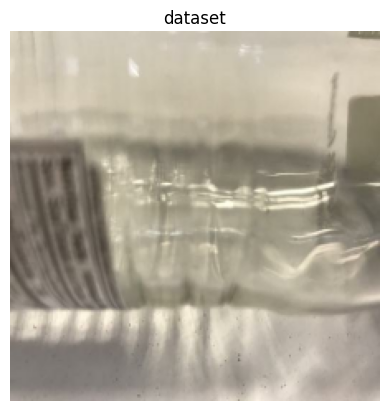

In [17]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[labels[0]])
    plt.axis("off")

In [18]:
import json

from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

In [19]:
IMG_SIZE =(224,224)
BATCH_SIZE =32
SEED = 42

#define DATA_DIR el path de kagglehub download
DATA_DIR = os.path.join(dataset_path, 'dataset')

train_data_path = os.path.join(DATA_DIR, 'Training')
test_data_path = os.path.join(DATA_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds.class_names
print("Clases Detectadas",class_names)
#

Found 2508 files belonging to 6 classes.
Clases Detectadas ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


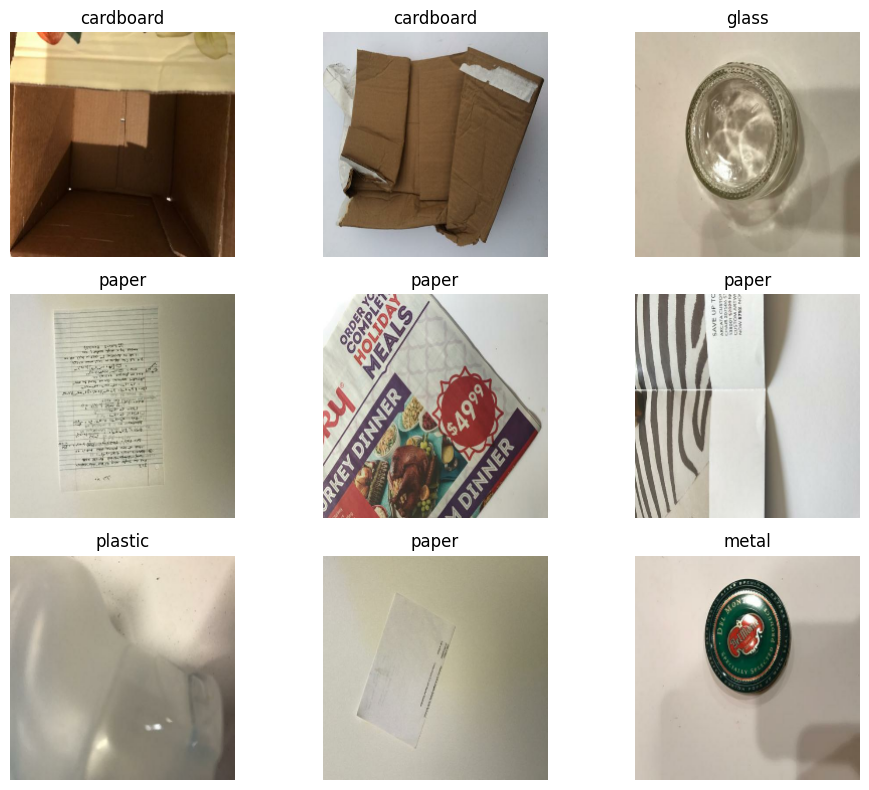

In [20]:
plt.figure(figsize=(10,8))
for images,labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

  plt.tight_layout()
  plt.show()
#


Este fragmento de codigo prepara los conjuntos de datos de entrenamiento (train_ds) y validacion (val_ds) para ser utilizado por un modelo MobileNetV2 en TensorFlow. Primero, AUTOTUNE permite que TensorFlow optimice automaticamente el uso de recursos al cargar los datos. Luego preprocess_input
aplica el preprocesamiento especifico de MobileNetV2 transformando los valores de los pixeles de las imagenes al formato esperado por esta red neuronal. Con map(), cada imagen (x) se comvierte al tipo float32 mediante tf.cast() y posteriormente se preprocesa, mientras que las etiquetas (y) permanecen sin cambios. Finalmente prefetch(AYTOTUNE) carga los siguientes lotes de datos en segundo plano mientras el modelo esta entrenando, mejorando el rendimiento y reduciendo los tiempos de espera durante el entrenamiento.

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Initialize val_ds before it's used
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_data_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

Found 464 files belonging to 6 classes.


In [22]:
#Crear el modelo mobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,),
    include_top=False,
  weights='imagenet'
  )
base_model.trainable = False
inputs = tf.keras.Input(shape=IMG_SIZE+(3,))
x = base_model(inputs,training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(len(class_names),activation='softmax')(x)

model=tf.keras.Model(inputs,outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenar

para probar rapido usa eEPOCHS=1.

In [23]:
EPOCHS = 1

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,  # con 2 epochs consecutivas, no aprende
        restore_best_weights=True
        )
    ]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
    )
#

79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.5989 - loss: 1.1042 - val_accuracy: 0.7328 - val_loss: 0.7725


In [24]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"Accuracy:{acc:.4f}")
#

Loss: 0.7725
Accuracy:0.7328


In [25]:
model.save("modelo_reciclaje.keras")
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

from google.colab import files
files.download("modelo_reciclaje.keras")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>